In [1]:
import os
from pathlib import Path
import pickle
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, LSTM, Dropout, Dense
from tensorflow.keras.models import load_model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing

## Create label mapping

In [3]:
data_dir = Path("/content/drive/MyDrive/Lip Landmark Dataset/landmark_dataset")

train_data_dir = data_dir / "train"
words = sorted([f.name for f in train_data_dir.iterdir() if f.is_dir()])
word_to_idx = {word: i for i, word in enumerate(words)}
idx_to_word = {i: word for word, i in word_to_idx.items()}

print(word_to_idx)

{'a': 0, 'again': 1, 'at': 2, 'b': 3, 'bin': 4, 'blue': 5, 'by': 6, 'c': 7, 'd': 8, 'e': 9, 'eight': 10, 'f': 11, 'five': 12, 'four': 13, 'g': 14, 'green': 15, 'h': 16, 'i': 17, 'in': 18, 'j': 19, 'k': 20, 'l': 21, 'lay': 22, 'm': 23, 'n': 24, 'nine': 25, 'now': 26, 'o': 27, 'one': 28, 'p': 29, 'place': 30, 'please': 31, 'q': 32, 'r': 33, 'red': 34, 's': 35, 'set': 36, 'seven': 37, 'six': 38, 'soon': 39, 't': 40, 'three': 41, 'two': 42, 'u': 43, 'v': 44, 'white': 45, 'with': 46, 'x': 47, 'y': 48, 'z': 49, 'zero': 50}


## Split dataset into input/output

In [ ]:
x = []
y = []

for word in tqdm(words):
    train_word_dir = Path(train_data_dir) / word

    for file in train_word_dir.iterdir():
        arr = np.load(file)
        x.append(arr)
        y.append(word_to_idx[word])

x = np.array(x, dtype=np.float32)   # (N, 30, 80)
y = np.array(y)                     # (N,)

100%|██████████| 51/51 [24:07<00:00, 28.37s/it]


In [4]:
save_path_x = Path(data_dir) / "x.npy"
save_path_y = Path(data_dir) / "y.npy"

In [ ]:
np.save(save_path_x, x)
np.save(save_path_y, y)

In [5]:
x = np.load(save_path_x)
y = np.load(save_path_y)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

In [9]:
x_train.shape, y_train.shape

((20210, 16, 80), (20210,))

In [10]:
x_test.shape, y_test.shape

((5053, 16, 80), (5053,))

In [11]:
unique, counts = np.unique(y_train, return_counts=True)
label_counts = {idx_to_word[idx]: count for idx, count in zip(unique, counts)}

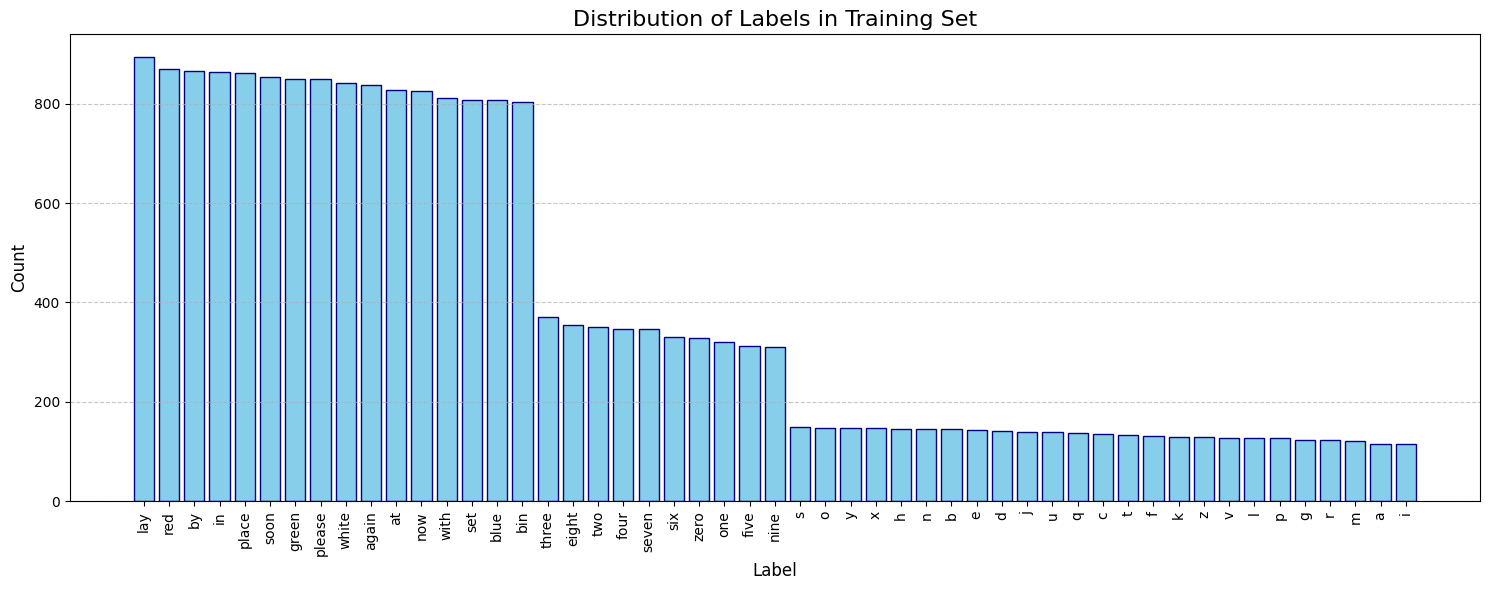

In [12]:
sorted_data = dict(sorted(label_counts.items(), key=lambda item: item[1], reverse=True))

keys = list(sorted_data.keys())
values = list(sorted_data.values())

plt.figure(figsize=(15, 6))
plt.bar(keys, values, color='skyblue', edgecolor='navy')

plt.title('Distribution of Labels in Training Set', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)  # Rotate labels so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [13]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights_dict = dict(zip(classes, class_weights))

# Model Creation

In [14]:
MAX_SIZE = 16
SEQ_LENGTH = 80

In [15]:
model = Sequential([
    Input(shape=(MAX_SIZE, SEQ_LENGTH)),
    Masking(mask_value=0.0),

    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(len(words), activation='softmax')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 16, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16, 128)        │       107,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 51)             │         3,315 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,891 (640.20 KB)

 Trainable params: 163,891 (640.20 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [ ]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict
)

Epoch 1/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1254 - loss: 3.2122 - val_accuracy: 0.1858 - val_loss: 2.8972
Epoch 2/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1854 - loss: 2.8947 - val_accuracy: 0.1961 - val_loss: 2.8338
Epoch 3/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2105 - loss: 2.7928 - val_accuracy: 0.2405 - val_loss: 2.6830
Epoch 4/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2619 - loss: 2.5866 - val_accuracy: 0.2976 - val_loss: 2.4489
Epoch 5/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2967 - loss: 2.4251 - val_accuracy: 0.3248 - val_loss: 2.3455
Epoch 6/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3201 - loss: 2.3240 - val_accuracy: 0.3317 - val_loss: 2.2723
Epoch 7/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3419 - loss: 2.2474 - val_accuracy: 0.3637 - val_loss: 2.1659
Epoch 8/100
632/632 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3538 - loss: 2.1876 - val

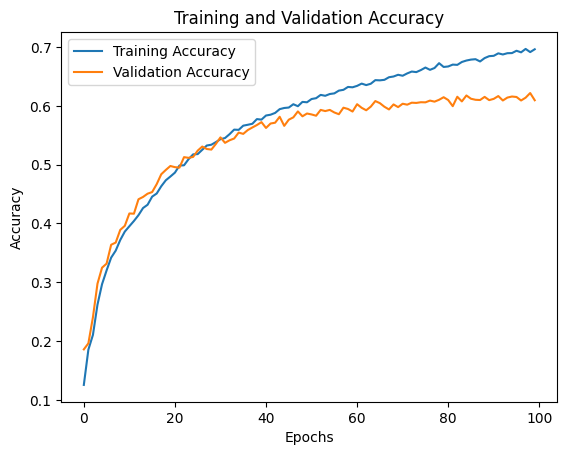

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Saving the model

In [ ]:
model.save("lip_reading_model.h5")

In [ ]:
with open("label_map.pkl", "wb") as f:
    pickle.dump(word_to_idx, f)

# Load model for inference

In [ ]:
model = load_model("lip_reading_model.h5")

with open("label_map.pkl", "rb") as f:
    word_to_idx = pickle.load(f)

idx_to_word = {v: k for k, v in word_to_idx.items()}